In [981]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Paso 1: Planteamiento del problema

>El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.

## Paso 2: Exploración y limpieza de datos

In [982]:
archivo = "../data/raw/diabetes.csv"
df = pd.read_csv(archivo)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## Paso 3: Análisis Descriptivo

In [983]:
df.shape

(768, 9)

In [984]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Paso 4: Limpieza de Datos

In [985]:
df.duplicated().sum()

np.int64(0)

### Limpieza de datos: Eliminar información irrelevante

>No hay ningún dato que parezca duplicado y pudimos ver el dataset y sus caracteristicas generales.

## Paso 5: Análisis de Variables

In [986]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


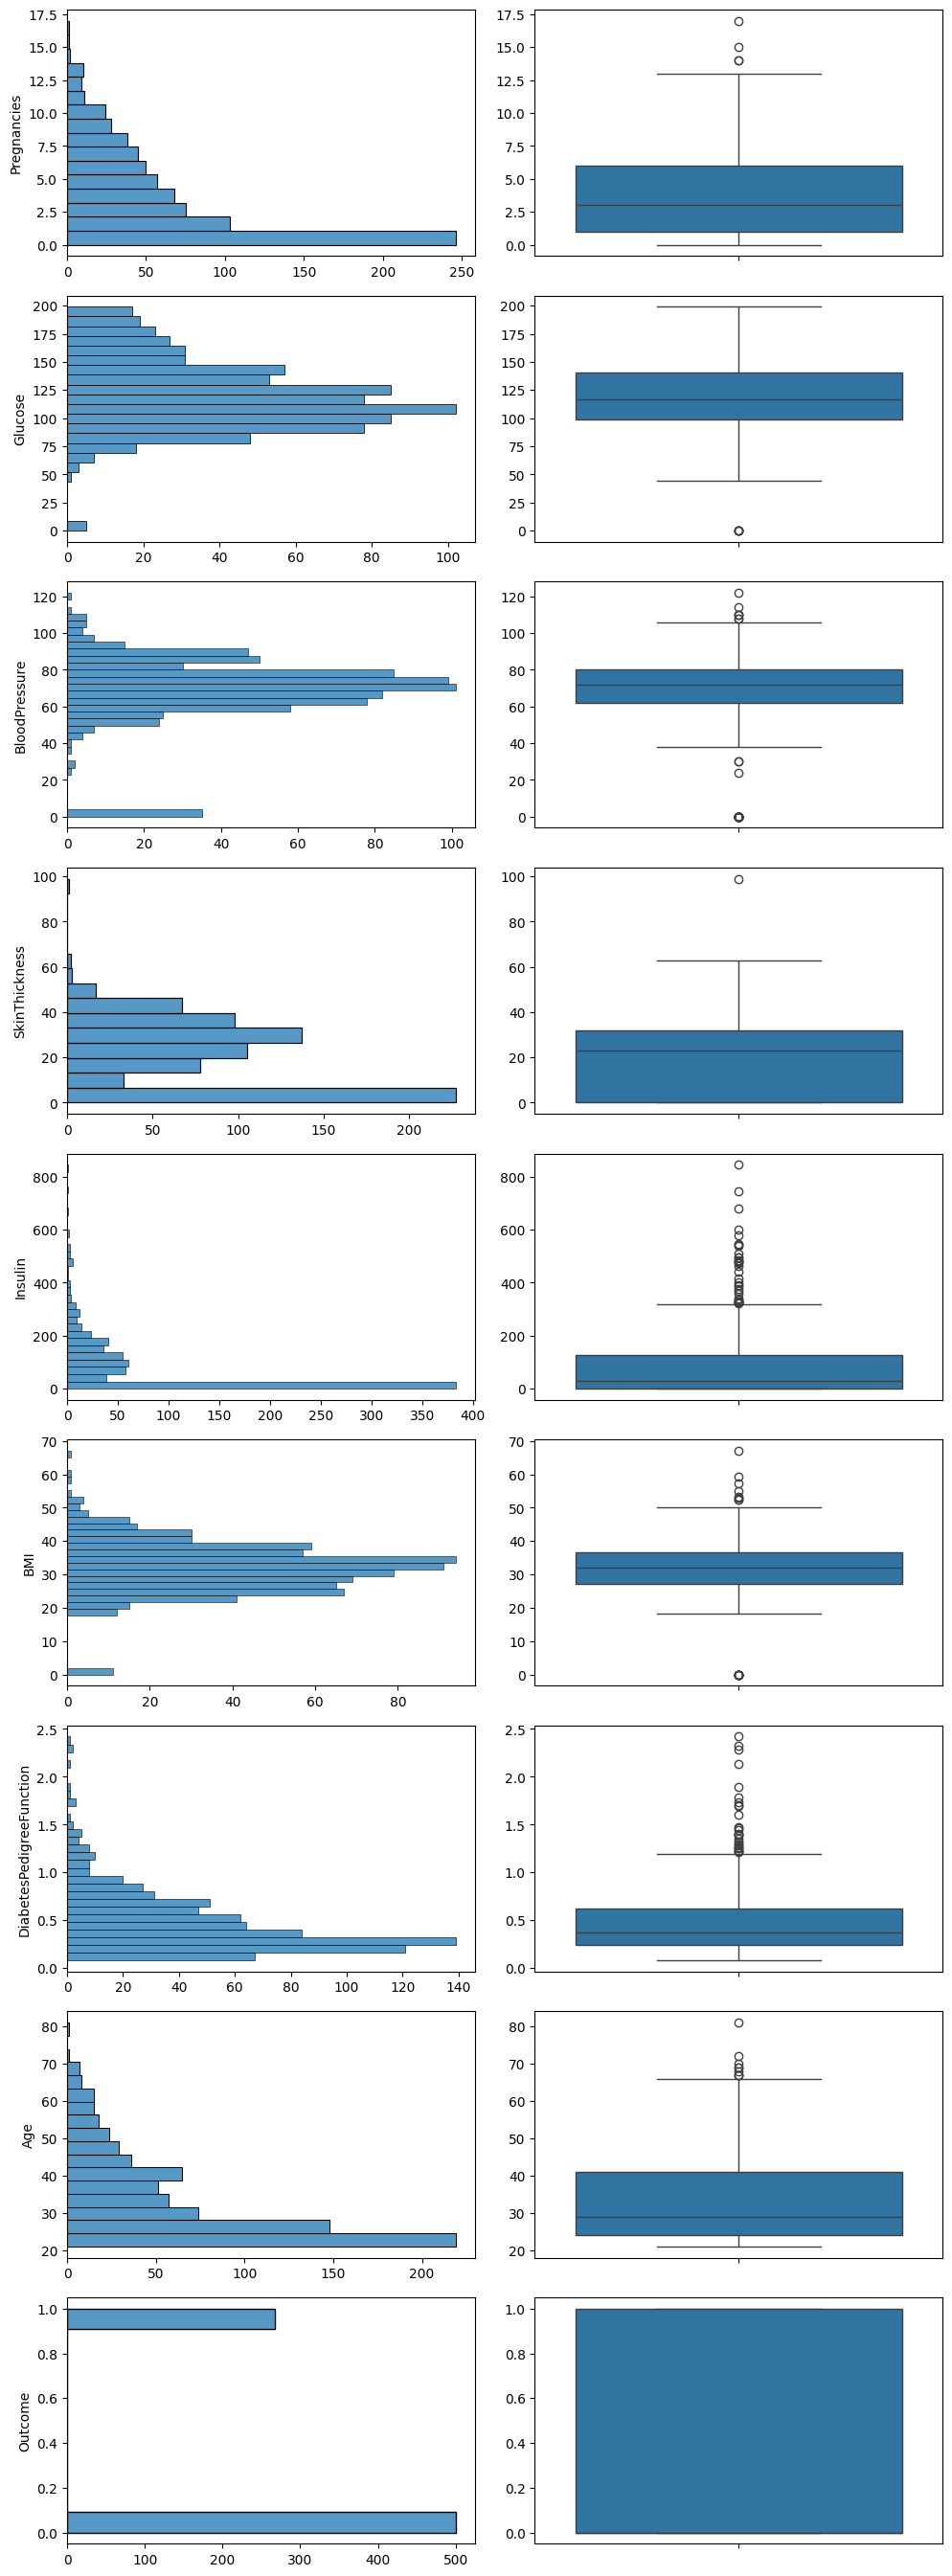

In [987]:
num_variables = df.select_dtypes(include=['int64','float64']).columns.tolist()


fig, axis = plt.subplots(len(num_variables), 2, figsize=(10, 3*len(num_variables)))

for i, var in enumerate(num_variables):
    sns.histplot(ax=axis[i, 0], data=df, y=var).set(xlabel=None)
    sns.boxplot(ax=axis[i, 1], data=df, y=var).set(ylabel=None)


plt.tight_layout()
plt.show()

### Observaciones

>Se observan ceros en variables donde no deberían existir fisiológicamente, como `Glucose, BloodPressure, SkinThickness, Insulin y BMI`.
>
>Estos 0 se interpretan como valores faltantes codificados, por lo que conviene tratarlos
>
>Crearemos un df_copy para conservar los valores del Df original y la copia recibirá la limpieza de lo que consideremos. Empezaremos cambiando los 0 por null para poderlos visualizar mejor.

In [988]:
df_copy = df.copy(deep = True)
df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)

## showing the count of Nans
df_copy.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

>Visualizaremos las filas que en simultaneo carecen de las variables `SkinThickness, Insulin, BloodPressure` ya que nos darian mucho ruido al modelo si no sustituimos todos los valores.

In [989]:
cols = ["SkinThickness", "Insulin", "BloodPressure"]
mask_both_missing = df_copy[cols].isna().all(axis=1)
both_missing_df = df_copy.loc[mask_both_missing].copy()

both_missing_df.shape

(33, 9)

>Sabiendo que hay 33 filas que carecen de 3 valores importantes en simultaneo escogeremos borrarlo.

In [990]:
df_copy = df_copy.loc[~mask_both_missing].copy()

>Volvemos a visualizar los valores nulos que tenemos y procederemos a seguir evaluando las decisiones que podemos tomar.

In [991]:
df_copy.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                 2
SkinThickness               194
Insulin                     341
BMI                           4
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

>Tenemos muchos valores faltantes en `SkinThickness y Insulin`, verificaremos la correlatividad entre `SkinThickness` y `BMI`, si tienen correlacion podriamos eliminar los datos que tengan nulos en ambos casos, en el restante podriamos luego de forma mas precisa con ayuda de uno poner un valor mas coherente al otro en caso de requerirlo.

In [992]:
corr = df_copy["SkinThickness"].corr(df_copy["BMI"], method="pearson")
corr

np.float64(0.6482139430923205)

In [993]:
cols = ["BMI", "SkinThickness"]
mask_both_missing = df_copy[cols].isna().all(axis=1)
both_missing_df = df_copy.loc[mask_both_missing].copy()

both_missing_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1
684,5,136.0,82.0,NaN,NaN,NaN,0.640,69,0


In [994]:
df_copy = df_copy.loc[~mask_both_missing].copy()

In [995]:
df_copy.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                 2
SkinThickness               192
Insulin                     339
BMI                           2
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

>Aplicamos el mismo metodo que usamos con las correlaciones para `Glucose` y `Insulin`

In [996]:
corr = df_copy["Glucose"].corr(df_copy["Insulin"], method="pearson")
corr

np.float64(0.581186208912165)

In [997]:
cols = ["Glucose", "Insulin"]
mask_both_missing = df_copy[cols].isna().all(axis=1)
both_missing_df = df_copy.loc[mask_both_missing].copy()

both_missing_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,NaN,48.0,20.0,NaN,24.7,0.140,22,0
342,1,NaN,68.0,35.0,NaN,32.0,0.389,22,0
349,5,NaN,80.0,32.0,NaN,41.0,0.346,37,1
502,6,NaN,68.0,41.0,NaN,39.0,0.727,41,1


In [998]:
df_copy = df_copy.loc[~mask_both_missing].copy()

In [999]:
df_copy.isnull().sum()

Pregnancies                   0
Glucose                       1
BloodPressure                 2
SkinThickness               192
Insulin                     335
BMI                           2
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

>Visualizamos los datos y empezamos a tomar decisiones. Ahora mismo nos enfocaremos en `glucose` y decidiremos que hacer con ello.

In [1000]:
cols = ["Glucose"]
mask_both_missing = df_copy[cols].isna().all(axis=1)
both_missing_df = df_copy.loc[mask_both_missing].copy()

both_missing_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
182,1,NaN,74.0,20.0,23.0,27.7,0.299,21,0


In [1001]:
mask = (df_copy["Age"] == 21) & (df_copy["Outcome"] == 0)
both_missing_df = df_copy.loc[mask].copy()
both_missing_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,57.0,1.105263,1.029636,0.000,0.000,1.000,2.000,4.000
Glucose,56.0,107.910714,18.532798,71.000,95.500,103.500,124.250,143.000
BloodPressure,57.0,66.666667,12.019825,24.000,60.000,64.000,74.000,96.000
SkinThickness,47.0,22.851064,8.742646,8.000,17.000,22.000,27.000,50.000
Insulin,33.0,121.030303,104.188676,18.000,61.000,87.000,152.000,480.000
BMI,55.0,28.449091,6.286696,18.200,24.450,27.400,31.700,43.500
DiabetesPedigreeFunction,57.0,0.417789,0.277540,0.078,0.223,0.368,0.545,1.731
Age,57.0,21.000000,0.000000,21.000,21.000,21.000,21.000,21.000
Outcome,57.0,0.000000,0.000000,0.000,0.000,0.000,0.000,0.000


In [1002]:
mask = df_copy["Glucose"].isna()
df_copy.loc[mask, "Glucose"] = 107.91

In [1003]:
df_copy.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 2
SkinThickness               192
Insulin                     335
BMI                           2
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

>Para `Glucose` buscamos personas que tenian su edad y dieron 0 en el target. nos quedamos con la media.
>
>Ahora veremos `BloodPressure` y tomaremos decisiones referente a esos valores.

In [1004]:
cols = ["BloodPressure"]
mask_both_missing = df_copy[cols].isna().all(axis=1)
both_missing_df = df_copy.loc[mask_both_missing].copy()

both_missing_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
172,2,87.0,NaN,23.0,NaN,28.9,0.773,25,0
357,13,129.0,NaN,30.0,NaN,39.9,0.569,44,1


In [1005]:
df_copy = df_copy.loc[~mask_both_missing].copy()

In [1006]:
df_copy.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness               192
Insulin                     333
BMI                           2
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

>En este caso notamos que una fila daba positivo en el target y otra negativo. tomamos la decision de eliminar las 2 filas ya que tenemos dificultades con simular `BloodPressure`.
>
>Ahora revisaremos `BMI`.

In [1007]:
cols = ["BMI"]
mask_both_missing = df_copy[cols].isna().all(axis=1)
both_missing_df = df_copy.loc[mask_both_missing].copy()

both_missing_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
145,0,102.0,75.0,23.0,NaN,NaN,0.572,21,0
371,0,118.0,64.0,23.0,89.0,NaN,1.731,21,0


In [1008]:
mask = (df_copy["Age"] == 21) & (df_copy["SkinThickness"] == 23.0)
both_missing_df = df_copy.loc[mask].copy()
both_missing_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
145,0,102.0,75.0,23.0,NaN,NaN,0.572,21,0
163,2,100.0,64.0,23.0,NaN,29.7,0.368,21,0
371,0,118.0,64.0,23.0,89.0,NaN,1.731,21,0
507,1,130.0,60.0,23.0,170.0,28.6,0.692,21,0
508,2,84.0,50.0,23.0,76.0,30.4,0.968,21,0


In [1009]:
both_missing_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,6.0,1.000000,0.894427,0.000,0.250,1.000,1.750,2.000
Glucose,6.0,103.833333,17.417424,84.000,91.750,101.000,114.000,130.000
BloodPressure,6.0,63.166667,8.158840,50.000,61.000,64.000,65.500,75.000
SkinThickness,6.0,23.000000,0.000000,23.000,23.000,23.000,23.000,23.000
Insulin,4.0,107.250000,42.515683,76.000,85.750,91.500,113.000,170.000
BMI,4.0,29.200000,1.042433,28.100,28.475,29.150,29.875,30.400
DiabetesPedigreeFunction,6.0,0.749667,0.553307,0.167,0.419,0.632,0.899,1.731
Age,6.0,21.000000,0.000000,21.000,21.000,21.000,21.000,21.000
Outcome,6.0,0.000000,0.000000,0.000,0.000,0.000,0.000,0.000


In [1010]:
mask = df_copy["BMI"].isna()
df_copy.loc[mask, "BMI"] = 29.2

In [1011]:
df_copy.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness               192
Insulin                     333
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

>Para `BMI` notamos que hay filas donde tienen valores parecidos sustituiremos con la media para poder completar las filas que faltan.
>
>Ahora nos enfocaremos en las filas donde tenemos tantos datos faltantes. Primero visualizaremos con ayuda de unos gráficos para ver como estan los datos con los cambios que hemos hecho.

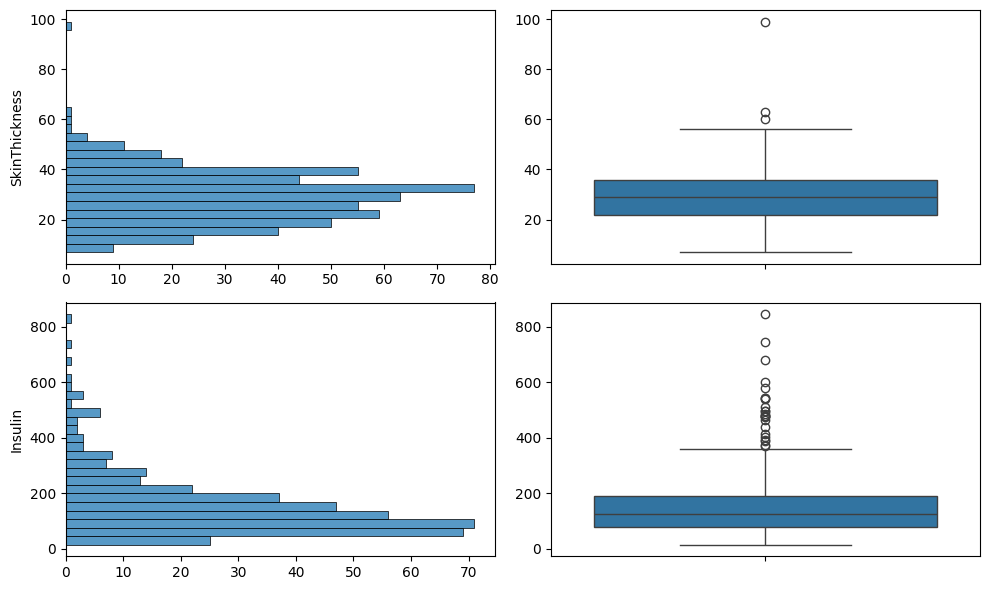

In [1012]:
num_variables = ["SkinThickness", "Insulin"]


fig, axis = plt.subplots(len(num_variables), 2, figsize=(10, 3*len(num_variables)))

for i, var in enumerate(num_variables):
    sns.histplot(ax=axis[i, 0], data=df_copy, y=var).set(xlabel=None)
    sns.boxplot(ax=axis[i, 1], data=df_copy, y=var).set(ylabel=None)


plt.tight_layout()
plt.show()

>Tomaremos la iniciativa con `Insulin` y empezaremos a verla mas en detalle para tomar decisiones.

In [1013]:
cols = ["Insulin"]
mask_both_missing = df_copy[cols].isna().all(axis=1)
both_missing_df = df_copy.loc[mask_both_missing].copy()

both_missing_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0
10,4,110.0,92.0,NaN,NaN,37.6,0.191,30,0
...,...,...,...,...,...,...,...,...,...
761,9,170.0,74.0,31.0,NaN,44.0,0.403,43,1
762,9,89.0,62.0,NaN,NaN,22.5,0.142,33,0
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,0
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,1


In [1014]:
both_missing_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,333.0,4.519520,3.423485,0.000,2.00,4.000,7.000,14.000
Glucose,333.0,120.945946,30.613458,44.000,101.00,114.000,139.000,199.000
BloodPressure,333.0,74.453453,11.919980,44.000,66.00,74.000,82.000,122.000
SkinThickness,141.0,29.241135,10.557259,8.000,22.00,30.000,36.000,99.000
Insulin,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,333.0,31.728529,6.649540,18.200,26.80,31.200,35.700,52.900
DiabetesPedigreeFunction,333.0,0.418222,0.306573,0.078,0.21,0.303,0.551,1.893
Age,333.0,36.240240,12.794104,21.000,25.00,33.000,44.000,70.000
Outcome,333.0,0.357357,0.479942,0.000,0.00,0.000,1.000,1.000


In [1015]:
df_copy["Insulin"] = df_copy["Insulin"].fillna(df_copy.groupby("Outcome")["Insulin"].transform("median"))

>Como sabemos que la insulina dependiendo del valor afecta el resultado, rellenamos con la mediana segun el grupo del target, donde el grupo con 0 tiene una mediana y el grupo con 1 tiene otra.
>
>Luego repetiremos el mismo proceso para la SkinThickness donde nos falten valores.

In [1016]:
cols = ["SkinThickness"]
mask_both_missing = df_copy[cols].isna().all(axis=1)
both_missing_df = df_copy.loc[mask_both_missing].copy()

both_missing_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2,8,183.0,64.0,NaN,169.5,23.3,0.672,32,1
5,5,116.0,74.0,NaN,102.5,25.6,0.201,30,0
10,4,110.0,92.0,NaN,102.5,37.6,0.191,30,0
11,10,168.0,74.0,NaN,169.5,38.0,0.537,34,1
12,10,139.0,80.0,NaN,102.5,27.1,1.441,57,0
...,...,...,...,...,...,...,...,...,...
757,0,123.0,72.0,NaN,169.5,36.3,0.258,52,1
758,1,106.0,76.0,NaN,102.5,37.5,0.197,26,0
759,6,190.0,92.0,NaN,169.5,35.5,0.278,66,1
762,9,89.0,62.0,NaN,102.5,22.5,0.142,33,0


In [1017]:
both_missing_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,192.0,4.833333,3.321094,0.000,2.00000,5.000,7.00000,13.000
Glucose,192.0,124.244792,30.001701,44.000,105.00000,122.000,142.25000,197.000
BloodPressure,192.0,74.880208,12.265015,48.000,66.00000,74.000,80.50000,122.000
SkinThickness,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Insulin,192.0,127.625000,32.521036,102.500,102.50000,102.500,169.50000,169.500
BMI,192.0,31.294792,6.791585,18.200,25.97500,31.050,35.15000,52.900
DiabetesPedigreeFunction,192.0,0.396625,0.282210,0.078,0.20475,0.287,0.53625,1.781
Age,192.0,38.161458,13.052049,21.000,27.00000,36.000,46.00000,69.000
Outcome,192.0,0.375000,0.485389,0.000,0.00000,0.000,1.00000,1.000


In [1018]:
df_copy["SkinThickness"] = df_copy["SkinThickness"].fillna(df_copy.groupby("Outcome")["SkinThickness"].transform("median"))

In [1019]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 727 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               727 non-null    int64  
 1   Glucose                   727 non-null    float64
 2   BloodPressure             727 non-null    float64
 3   SkinThickness             727 non-null    float64
 4   Insulin                   727 non-null    float64
 5   BMI                       727 non-null    float64
 6   DiabetesPedigreeFunction  727 non-null    float64
 7   Age                       727 non-null    int64  
 8   Outcome                   727 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 56.8 KB


> Tenemos un dataset limpio, lo visualizaremos en comparacion a como estaba antes y como esta ahora.

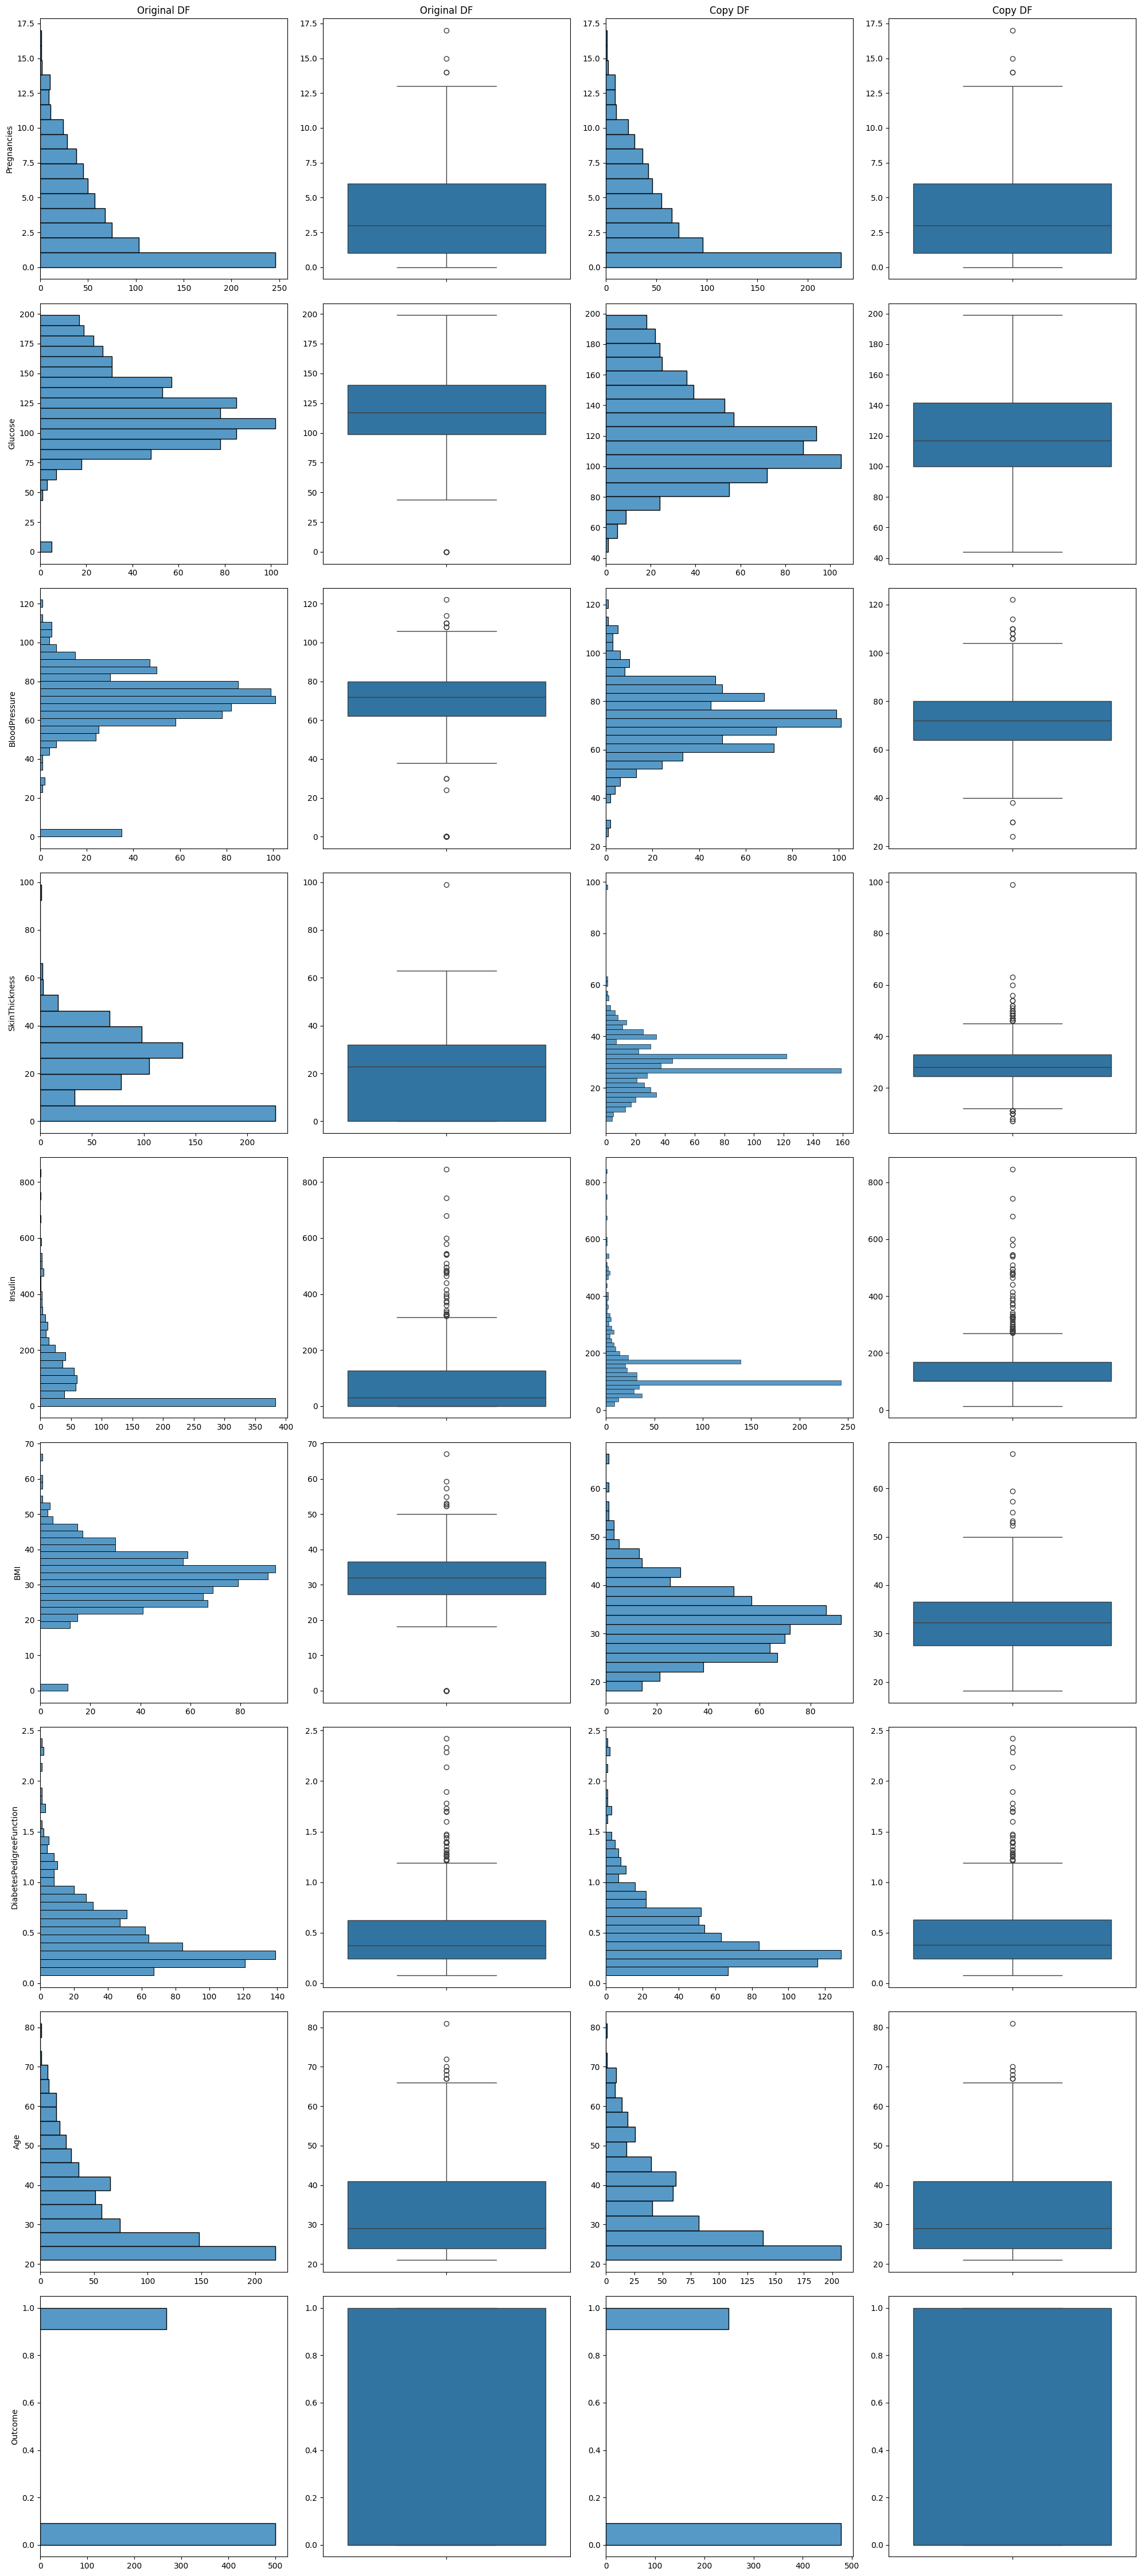

In [1020]:
num_variables = df.select_dtypes(include=['int64','float64']).columns.tolist()
foo = "Original DF"
bat = "Copy DF"

fig, axis = plt.subplots(len(num_variables), 4, figsize=(20, 5*len(num_variables)))
for i, var in enumerate(num_variables):
    if i > 0:
        foo = None
        bat = None    
    sns.histplot(ax=axis[i, 0], data=df, y=var).set(title=foo, xlabel=None)
    sns.boxplot(ax=axis[i, 1], data=df, y=var).set(ylabel=None, title=foo, xlabel=None)
    sns.histplot(ax=axis[i, 2], data=df_copy, y=var).set(title=bat, ylabel=None, xlabel=None)
    sns.boxplot(ax=axis[i, 3], data=df_copy, y=var).set(ylabel=None, title=bat, xlabel=None)


plt.tight_layout()
plt.show()

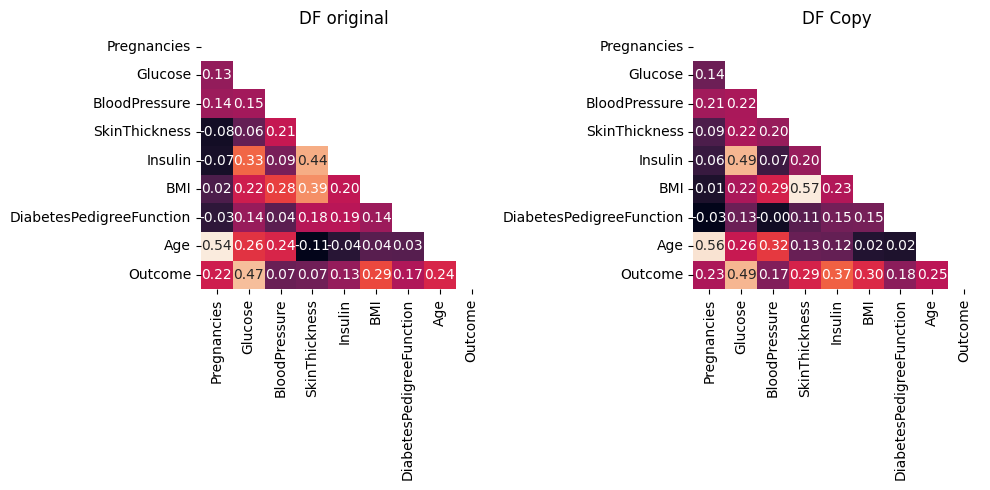

In [1021]:
corr_y = df[num_variables].corr(numeric_only=True)
corr_copy_y = df_copy[num_variables].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_y, dtype=bool))
mask_copy_y = np.triu(np.ones_like(corr_copy_y, dtype=bool))
fig, axis = plt.subplots(1, 2, figsize=(10, 5))
sns.heatmap(ax=axis[0], data=corr_y, annot=True, fmt=".2f", cbar=False, mask=mask)
axis[0].set_title("DF original")
sns.heatmap(ax=axis[1], data=corr_copy_y, annot=True, fmt=".2f", cbar=False, mask=mask_copy_y)
axis[1].set_title("DF Copy")

plt.tight_layout()
plt.show()

## Conclusiones

>Comparamos los gráficos del DF original con los modificados, con la modificación ya no tenemos valores en 0, los que eran irreales. tendremos un estándar con las variables que existían y eso nos data un mejor modelo.
>
>Procederemos a guardar los datos para luego normalizarlos en los modelos que necesitemos despues de hacer el respectivo split.

In [1022]:
df_copy.to_csv("/workspaces/AnthonnyMal-Machine-Learnig/data/processed/df_diabetes", index=False)